# Step 10: Live demo

Shows the data the group collected **after** the history download
(8 Oct 2026 10:00 UTC onward) as a stream, and checks each grid cell that got
new events with the Isolation Forest from Step 6.

**For the video (in this order):**
1. Set `FETCH_NOW = True` below and run the notebook: it runs `usgs_fetch.py`
   once, so the viewer sees new events arriving from the USGS API.
2. Play the replay map (section 3): events appear in time order, as if streaming in.
3. Show the anomaly table (section 4): is any cell behaving unusually this week?

With `FETCH_NOW = False` (default) the notebook only reads the file, so it also
works offline. Record a backup screen capture before the video day.

In [1]:
import sys, json, subprocess
from pathlib import Path
sys.path.append("../scripts")
import config as cfg

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import plotly.graph_objects as go

FETCH_NOW = False                                        # True = pull new events from USGS first
LIVE_START = pd.Timestamp("2026-10-08 10:00", tz="UTC")  # end of the history download (plan, Step 1-2)

ROOT, RESULTS_DIR, FIGURES_DIR, MODELS_DIR = cfg.ROOT, cfg.RESULTS_DIR, cfg.FIGURES_DIR, cfg.MODELS_DIR
EARTH_KM = 6371.0088

# same look as the other notebooks
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
BACKDROP = "#c9c8c2"
DEPTH_COLORS = {"shallow": "#86b6ef", "intermediate": "#2a78d6", "deep": "#104281"}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left", "font.size": 10,
})

## 1. Fetch new events from USGS (only when `FETCH_NOW = True`)

In [2]:
def n_rows():
    return sum(1 for _ in open(cfg.RAW_FILE, encoding="utf-8")) - 1

if FETCH_NOW:
    before = n_rows()
    out = subprocess.run([sys.executable, str(ROOT / "scripts" / "usgs_fetch.py")],
                         capture_output=True, text=True, cwd=ROOT)
    print(out.stdout[-3000:] or out.stderr[-3000:])
    print(f"rows in raw file: {before:,} -> {n_rows():,}")
else:
    print(f"FETCH_NOW is False: using the file as it is ({n_rows():,} rows)")

FETCH_NOW is False: using the file as it is (187,588 rows)


## 2. Load the live events
Live = first seen by our script **and** happened after `LIVE_START`. Filtering on
`time` too stops an old event that USGS re-issued under a new id from looking new.
The same basic cleaning as Step 3 is applied (drop deleted events, keep M ≥ 4.5).

In [3]:
raw = pd.read_csv(cfg.RAW_FILE, dtype={"id": str})
for c in ["time", "first_seen_at"]:
    raw[c] = pd.to_datetime(raw[c], utc=True, format="ISO8601")
ev = raw[(raw["type"] == "earthquake") & (raw["status"] != "deleted") & (raw["mag"] >= cfg.MIN_MAG)].copy()
ev["cell_id"] = [cfg.cell_id(a, b) for a, b in zip(ev["latitude"], ev["longitude"])]
ev["depth_class"] = pd.cut(ev["depth"], [-np.inf, 70, 300, np.inf], right=False,
                           labels=["shallow", "intermediate", "deep"]).astype(str)
ev["region"] = ev["place"].astype(str).str.split(",").str[-1].str.strip()

live = ev[(ev["first_seen_at"] > LIVE_START) & (ev["time"] > LIVE_START)].sort_values("time").reset_index(drop=True)
history = ev[ev["time"] <= LIVE_START]

span_h = (live["time"].max() - live["time"].min()).total_seconds() / 3600
summary = pd.DataFrame([
    {"item": "live window start (UTC)", "value": str(LIVE_START)},
    {"item": "latest event (UTC)", "value": str(live["time"].max())},
    {"item": "live events (M4.5+)", "value": len(live)},
    {"item": "hours covered", "value": round(span_h, 1)},
    {"item": "events per day", "value": round(len(live) / max(span_h / 24, 1e-9), 1)},
    {"item": "largest magnitude", "value": live["mag"].max()},
    {"item": "grid cells with new events", "value": live["cell_id"].nunique()},
    {"item": "fetch runs that found new events", "value": live["first_seen_at"].nunique()},
])
summary.to_csv(RESULTS_DIR / "step10_live_summary.csv", index=False)
live[["id", "time", "first_seen_at", "latitude", "longitude", "depth", "mag", "magType", "place", "cell_id"]] \
    .to_csv(RESULTS_DIR / "step10_live_events.csv", index=False)
display(summary)
live.nlargest(5, "mag")[["time", "mag", "depth", "place"]]

,item,value
0,live window start (UTC),2026-10-08 10:00:00+00:00
1,latest event (UTC),2026-10-10 10:35:11.922000+00:00
2,live events (M4.5+),69
3,hours covered,48.5
4,events per day,34.2
5,largest magnitude,7.7
6,grid cells with new events,24
7,fetch runs that found new events,1


,time,mag,depth,place
20,2026-10-09 17:56:06.036000+00:00,7.7,12.647,"12 km WSW of Pitaloza Arriba, Panama"
34,2026-10-09 20:25:39.080000+00:00,6.6,10.000,"14 km W of Río Grande, Panama"
56,2026-10-10 04:14:01.786000+00:00,6.0,10.000,"7 km N of La Tronosa, Panama"
16,2026-10-09 14:49:41.714000+00:00,5.9,10.000,west of Macquarie Island
22,2026-10-09 18:37:46.146000+00:00,5.8,10.000,"1 km S of El Cacao, Panama"


## 3. Replay: the live events as a stream
Press **Play**. Each frame adds the events of the next time step (orange = just
arrived, blue = earlier). The grey background is every M5+ event since 2000,
which traces the plate boundaries (no internet needed for the map).
The animation is also saved as `figures/step10_live_replay.html` to open in a browser.

In [4]:
step_h = max(1, int(np.ceil(span_h / 48)))                      # at most ~48 frames
t0 = live["time"].min().floor("h")
edges = pd.date_range(t0, live["time"].max().ceil("h") + pd.Timedelta(hours=step_h), freq=f"{step_h}h")

bg = history[history["mag"] >= 5.0][["latitude", "longitude"]].round(1).drop_duplicates()
size = lambda m: 6 + (m - cfg.MIN_MAG) * 7
hover = lambda d: [f"{t:%d %b %H:%M} UTC<br>M{m:.1f}, {z:.0f} km deep<br>{p}"
                   for t, m, z, p in zip(d["time"], d["mag"], d["depth"], d["place"])]

def frame_traces(t_end):
    old = live[live["time"] < t_end - pd.Timedelta(hours=step_h)]
    new = live[(live["time"] >= t_end - pd.Timedelta(hours=step_h)) & (live["time"] < t_end)]
    return [
        go.Scatter(x=old["longitude"], y=old["latitude"], mode="markers", name="earlier live events",
                   marker=dict(size=size(old["mag"]), color=BLUE, opacity=0.75, line=dict(width=1, color=SURFACE)),
                   text=hover(old), hoverinfo="text"),
        go.Scatter(x=new["longitude"], y=new["latitude"], mode="markers", name="arrived in this step",
                   marker=dict(size=size(new["mag"]) + 4, color=ORANGE, line=dict(width=1.5, color=SURFACE)),
                   text=hover(new), hoverinfo="text"),
    ]

def label(t_end):
    n = int((live["time"] < t_end).sum())
    return f"Live events up to {t_end:%d %b %H:%M} UTC: {n} of {len(live)}"

frames = [go.Frame(data=frame_traces(t), traces=[1, 2], name=str(i), layout=dict(title_text=label(t)))
          for i, t in enumerate(edges[1:])]
end = edges[-1] + pd.Timedelta(hours=step_h)          # opening view = everything collected so far
anim = dict(frame=dict(duration=350, redraw=True), transition=dict(duration=0), fromcurrent=True)
fig = go.Figure(
    data=[go.Scattergl(x=bg["longitude"], y=bg["latitude"], mode="markers", name="M5+ since 2000",
                       marker=dict(size=2, color=BACKDROP), hoverinfo="skip")] + frame_traces(end),
    frames=frames)
fig.update_layout(
    title=dict(text=f"All {len(live)} live events (press Play to replay them in time order)", x=0.01, y=0.97),
    template="simple_white", height=640, margin=dict(t=60, b=150, l=60, r=20),
    paper_bgcolor=SURFACE, plot_bgcolor=SURFACE, font=dict(color=INK),
    xaxis=dict(range=[-180, 180], title="Longitude (degrees)", dtick=60, showgrid=True, gridcolor=GRID,
               constrain="domain"),
    yaxis=dict(range=[-75, 85], title="Latitude (degrees)", dtick=30, showgrid=True, gridcolor=GRID,
               scaleanchor="x", scaleratio=1, constrain="domain"),
    legend=dict(orientation="h", y=1.0, x=1, xanchor="right", yanchor="bottom"),
    updatemenus=[dict(type="buttons", x=0, y=-0.2, xanchor="left", yanchor="top", direction="left",
                      pad=dict(t=0, r=10), buttons=[
        dict(label="▶ Play", method="animate", args=[None, anim]),
        dict(label="❚❚ Pause", method="animate",
             args=[[None], dict(frame=dict(duration=0, redraw=True), mode="immediate")])])],
    sliders=[dict(active=0, x=0.16, len=0.84, y=-0.2, yanchor="top", pad=dict(t=0),
                  currentvalue=dict(visible=False),
                  steps=[dict(method="animate", label=f"{t:%d %b %H:%M}" if i % 6 == 0 else "",
                              args=[[str(i)], dict(mode="immediate", frame=dict(duration=0, redraw=True))])
                         for i, t in enumerate(edges[1:])])],
)
fig.write_html(FIGURES_DIR / "step10_live_replay.html", include_plotlyjs=True, auto_play=False)
fig.show()

## 4. Is any cell unusual right now? (Isolation Forest from Step 6)
For every cell-week that got a live event, the Step 6 features are computed from
**all** events of that cell-week (including any before `LIVE_START`), exactly as in
`05_anomaly.ipynb`, and scored with the saved model (feature set B, without max
magnitude). Flag = score ≥ the saved cut-off. The current week is still running,
so its score can change as more events arrive.

In [5]:
spec = json.loads((MODELS_DIR / "isoforest_features.json").read_text())
iso = joblib.load(MODELS_DIR / "isoforest.joblib")

ev["week"] = ev["time"].dt.tz_localize(None).dt.to_period("W-SUN").dt.start_time
live["week"] = live["time"].dt.tz_localize(None).dt.to_period("W-SUN").dt.start_time
keys = live[["cell_id", "week"]].drop_duplicates()
sub = ev.merge(keys, on=["cell_id", "week"])

g = sub.groupby(["cell_id", "week"])
lat0, lon0 = g["latitude"].transform("mean"), g["longitude"].transform("mean")
la1, lo1, la2, lo2 = map(np.radians, (sub["latitude"], sub["longitude"], lat0, lon0))
a = np.sin((la2 - la1) / 2) ** 2 + np.cos(la1) * np.cos(la2) * np.sin((lo2 - lo1) / 2) ** 2
sub["km_to_centre"] = 2 * EARTH_KM * np.arcsin(np.sqrt(a))
cw = g.agg(n_events=("id", "size"), mean_mag=("mag", "mean"), max_mag=("mag", "max"),
           mean_depth=("depth", "mean"), spread_km=("km_to_centre", "mean"),
           region=("region", lambda s: s.mode().iloc[0])).reset_index()
base = cw["cell_id"].map(spec["baseline_weekly_rate"]).fillna(spec["baseline_floor"])
cw["normal_per_week"] = base.round(3)
cw["log_rate_ratio"] = np.log10(cw["n_events"] / base)
cw["score"] = -iso.score_samples(cw[spec["features"]])
cw["flagged"] = cw["score"] >= spec["cut_score"]
cw["week_complete"] = cw["week"] + pd.Timedelta(days=7) <= live["time"].max().tz_localize(None)

anom = cw.sort_values("score", ascending=False)[
    ["cell_id", "region", "week", "week_complete", "n_events", "normal_per_week", "mean_mag", "max_mag",
     "mean_depth", "spread_km", "score", "flagged"]].round({"mean_mag": 2, "mean_depth": 1, "spread_km": 1, "score": 3})
anom.to_csv(RESULTS_DIR / "step10_live_anomaly.csv", index=False)
print(f"{len(anom)} cell-weeks with live events, {int(anom.flagged.sum())} flagged "
      f"(cut-off {spec['cut_score']:.3f}, model trained on {spec['trained_on']})")
anom.head(10)

24 cell-weeks with live events, 0 flagged (cut-off 0.683, model trained on cell-weeks up to 2019-12-31)


,cell_id,region,week,week_complete,n_events,normal_per_week,mean_mag,max_mag,mean_depth,spread_km,score,flagged
23,5_-85,Panama,2026-10-05,False,35,0.443,5.05,7.7,10.5,49.1,0.677,False
9,-25_175,south of the Fiji Islands,2026-10-05,False,4,0.550,4.68,5.0,513.4,23.2,0.596,False
4,-20_-180,Fiji,2026-10-05,False,3,2.321,4.80,5.1,600.6,65.8,0.592,False
22,5_-80,Panama,2026-10-05,False,6,0.178,4.60,4.9,27.5,147.6,0.556,False
6,-20_165,Vanuatu,2026-10-05,False,3,2.108,5.43,6.3,18.3,49.3,0.511,False
13,0_125,Indonesia,2026-10-05,False,4,3.705,5.03,5.2,27.8,138.6,0.486,False
12,-65_150,west of Macquarie Island,2026-10-05,False,1,0.091,5.90,5.9,10.0,0.0,0.482,False
1,-10_150,Papua New Guinea,2026-10-05,False,2,3.328,4.75,4.8,96.5,121.1,0.470,False
11,-5_140,Papua New Guinea,2026-10-05,False,2,0.674,4.60,4.6,65.9,157.1,0.469,False
21,50_160,Russia,2026-10-05,False,3,0.510,4.77,4.8,17.8,137.6,0.464,False


## 5. Static map for the slides (`figures/step10_live_map.png`)

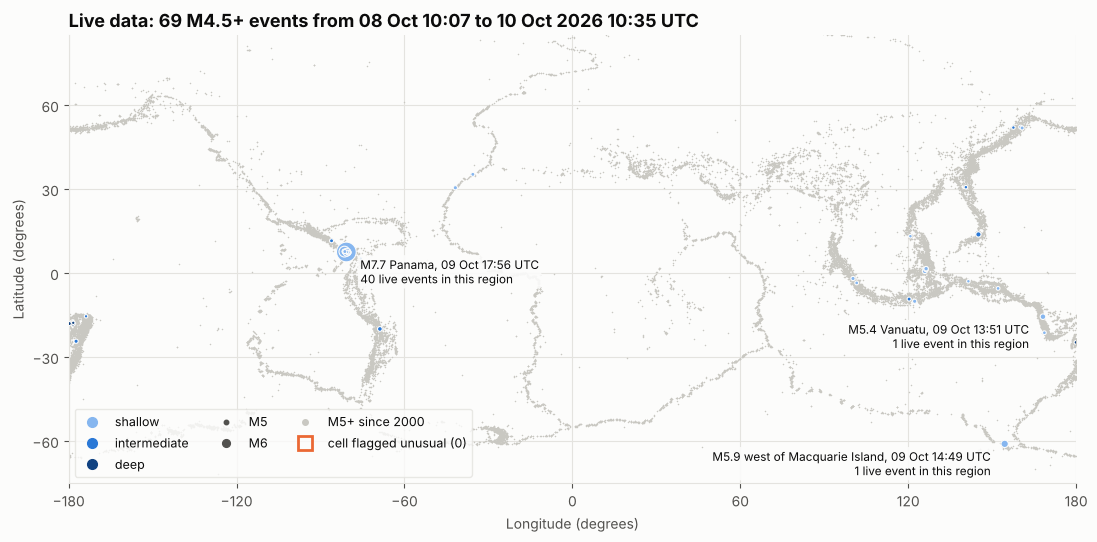

In [6]:
fig, ax = plt.subplots(figsize=(13, 6.6))
ax.scatter(bg["longitude"], bg["latitude"], s=1.2, c=BACKDROP, linewidths=0, rasterized=True)
msize = lambda m: 6 * 3.0 ** (m - cfg.MIN_MAG)
for cls in ["shallow", "intermediate", "deep"]:
    s = live[live["depth_class"] == cls]
    ax.scatter(s["longitude"], s["latitude"], s=msize(s["mag"]), c=DEPTH_COLORS[cls],
               edgecolors=SURFACE, linewidths=0.8, zorder=3)
G = cfg.GRID_DEG
for _, r in anom[anom["flagged"]].iterrows():
    la, lo = map(int, r["cell_id"].split("_"))
    ax.add_patch(Rectangle((lo, la), G, G, fill=False, ec=ORANGE, lw=2, zorder=4))
# label the 3 regions with the largest events (one label per region, so they don't pile up)
n_by_region = live.groupby("region").size()
for _, k in live.sort_values("mag", ascending=False).drop_duplicates("region").head(3).iterrows():
    n = n_by_region[k["region"]]
    right = k["longitude"] > 90                      # near the right edge: put the label on the left
    ax.annotate(f"M{k['mag']:.1f} {k['region']}, {k['time']:%d %b %H:%M} UTC\n"
                f"{n} live event{'s' if n != 1 else ''} in this region",
                (k["longitude"], k["latitude"]), xytext=(-10 if right else 10, -4), textcoords="offset points",
                ha="right" if right else "left", fontsize=8.5, va="top", color=INK,
                bbox=dict(boxstyle="round,pad=0.2", fc=SURFACE, ec="none", alpha=0.9), zorder=5)
ax.set_xlim(-180, 180); ax.set_ylim(-75, 85); ax.set_aspect("equal")
ax.set_xticks(range(-180, 181, 60)); ax.set_yticks(range(-60, 81, 30))
ax.set_xlabel("Longitude (degrees)"); ax.set_ylabel("Latitude (degrees)")
ax.set_title(f"Live data: {len(live)} M{cfg.MIN_MAG}+ events from {live['time'].min():%d %b %H:%M} "
             f"to {live['time'].max():%d %b %Y %H:%M} UTC")
handles = [Line2D([], [], ls="", marker="o", ms=7, color=DEPTH_COLORS[c], label=c) for c in DEPTH_COLORS]
handles += [Line2D([], [], ls="", marker="o", ms=np.sqrt(msize(m)), color=MUTED, label=f"M{m:g}") for m in (5, 6)]
handles += [Line2D([], [], ls="", marker="o", ms=4, color=BACKDROP, label="M5+ since 2000"),
            Line2D([], [], ls="", marker="s", ms=10, mfc="none", mec=ORANGE, mew=2,
                   label=f"cell flagged unusual ({int(anom.flagged.sum())})")]
ax.legend(handles=handles, loc="lower left", ncol=3, frameon=True, facecolor=SURFACE, edgecolor=GRID, fontsize=9)
fig.savefig(FIGURES_DIR / "step10_live_map.png", dpi=cfg.FIG_DPI, bbox_inches="tight")
plt.show()